DSC 440 Project #2 - AJ Jaber
Digit Recogition and Dimensionality Reduction

In this projeect, I will be working with the Kaggle Digit Recognizer dataset from the Getting started challenges. Each image is represented by 784 pixel features so (28×28) and the task is to classify which digit (0–9) the image represents.

Instead of just training one model and reporting accuracy, I want to explore how model performance changes when I reduce the dimensionality of the data using principal component analysis (PCA).

My main goal is to determine whether dimensionality reduction preserves performance while improving efficiency.

In [2]:
#all of my core libraries and imports
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#the maching learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

#for models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

#metrics
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

Loading Data

In [3]:
train_path = "/Users/ajjaber/Downloads/digit-recognizer/train.csv"
test_path = "/Users/ajjaber/Downloads/digit-recognizer/test.csv"
sample_sub_path = "/Users/ajjaber/Downloads/digit-recognizer/sample_submission.csv"

#loading the files
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_sub = pd.read_csv(sample_sub_path)

#quick check so I know the files loaded right
print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)
print("sample_sub shape:", sample_sub.shape)

train_df shape: (42000, 785)
test_df shape: (28000, 784)
sample_sub shape: (28000, 2)


In [4]:
#sneak peek at training data (just wanna confirm labels and pixels are there)
train_df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
random_row = X.iloc[10]
print("Number of non-zero pixels in this image:", np.count_nonzero(random_row))

Number of non-zero pixels in this image: 231


Separating Features

In [6]:
#the label column is the digit (0-9)
#everything else is pixel intensity values (784 columns)
y = train_df["label"].astype(int)
X = train_df.drop(columns=["label"])

#sanity checks 
print("X shape (should be rows x 784):", X.shape)
print("y shape:", y.shape)

#missing values check 
print("missing values in X:", int(X.isna().sum().sum()))

#confirming the label set is what I expect (0 to 9)
print("unique labels:", sorted(y.unique()))

#pixel intensity is grayscale
print("pixel min:", int(X.values.min()), "pixel max:", int(X.values.max()))
print("pixel mean (rough):", round(float(X.values.mean()), 2))

X shape (should be rows x 784): (42000, 784)
y shape: (42000,)
missing values in X: 0
unique labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
pixel min: 0 pixel max: 255
pixel mean (rough): 33.41


Train/Validation Split

In [8]:
#I split into train/validation so I can look at the models fairly
#stratify=y keeps the digit distribution consistent across both sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, "X_val:", X_val.shape)
print("y_train:", y_train.shape, "y_val:", y_val.shape)

X_train: (33600, 784) X_val: (8400, 784)
y_train: (33600,) y_val: (8400,)


Sample Digit Grid

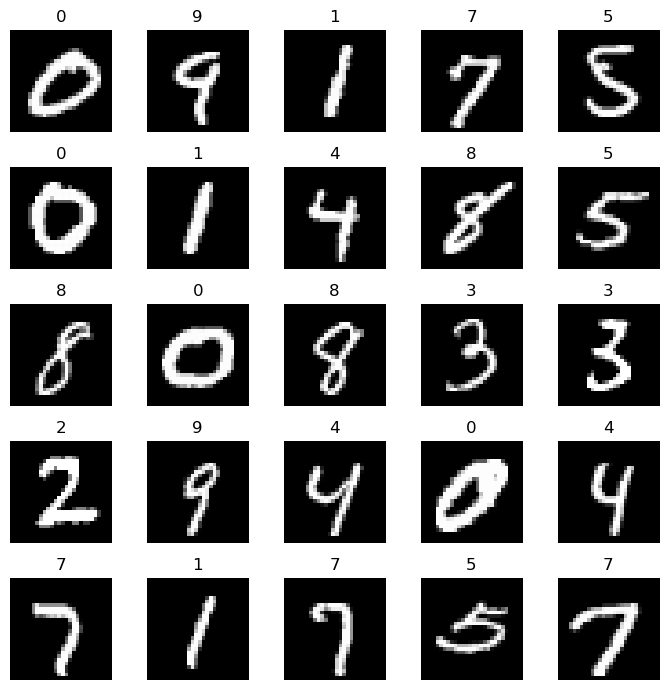

In [39]:
#I want to visually see that the 784 features actually form 28x28 images
#If these just look like static then something is wrong(ORRR the digits are hiding from me)
def plot_digit_grid(X_df, y_series, n=25, seed=7):
    rng=np.random.default_rng(seed)
    idx=rng.choice(len(X_df), size=n, replace=False)

    side= 28  #because 28x28=784
    plt.figure(figsize=(7, 7))

    for i, row_i in enumerate(idx, start=1):
        img = X_df.iloc[row_i].values.reshape(side, side)
        plt.subplot(5, 5, i)
        plt.imshow(img, cmap="gray")
        plt.title(str(y_series.iloc[row_i]))
        plt.axis("off") #-->forgot to add this the first time and was all confuzzled
    plt.tight_layout()
    plt.show()

plot_digit_grid(X, y, n=25, seed=7)

Label Distribution Graph

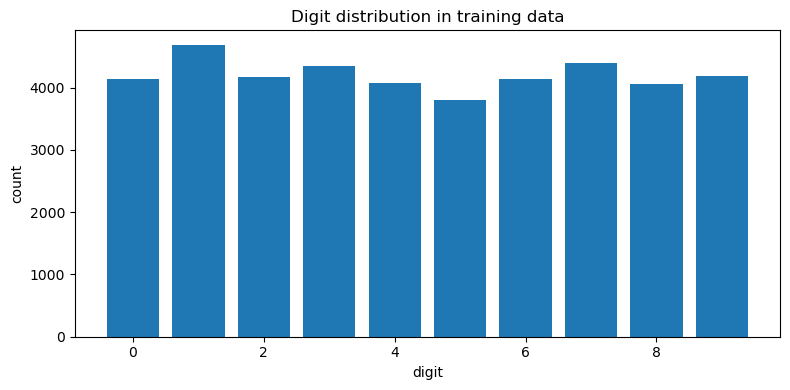

0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: label, dtype: int64

In [26]:
#before modeling I'll check if digits are roughly balanced
#(If a digit barely appears then models can struggle on that class)
label_counts = y.value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(label_counts.index, label_counts.values)
plt.xlabel("digit")
plt.ylabel("count")
plt.title("Digit distribution in training data")
plt.tight_layout()
plt.show()

#print counts too 
label_counts

A helper function for training

In [14]:
#Im using one function for training/evaluating so I don’t repeat code 3 billion times
#It returns a little result nd predictions(so I can reuse preds later if needed)
def fit_eval(model, name, X_train, y_train, X_val, y_val):
    # timing training so I can compare efficiency
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    #predictions on validation set (this is what I care about for performance)
    preds = model.predict(X_val)

    #accuracy=overall correctness
    acc = accuracy_score(y_val, preds)

    #macro F1= averages F1 across classes equally 
    f1 = f1_score(y_val, preds, average="macro")

    #package results in a clean format
    result = {
        "model": name,
        "accuracy": acc,
        "macro_f1": f1,
        "train_time_sec": train_time
    }

    return result, preds

Baseline Models (no PCA)

In [15]:
#Baseline= using all 784 pixel features
#gives me a starting poiint to compare against PCA later
baseline_results = []

#Logistic Regression
#I scale first because it’s a linear model and scaling helps a lot
#max_iter bumped up so it actually converges(...so it stops complaining)
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])
r, log_preds = fit_eval(log_model, "logreg (scaled)", X_train, y_train, X_val, y_val)
baseline_results.append(r)

#Linear SVM:
#benefits from scaling
#tends to do well on high-dimensional classification (like images)
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC())
])
r, svm_preds = fit_eval(svm_model, "linearsvc (scaled)", X_train, y_train, X_val, y_val)
baseline_results.append(r)

#Random Forest:
#tree based so scaling not needed
#can capture nonlinear patterns
#might be slower, but good to compare a different model type
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
r, rf_preds = fit_eval(rf_model, "randomforest", X_train, y_train, X_val, y_val)
baseline_results.append(r)

baseline_df = pd.DataFrame(baseline_results).sort_values(by="accuracy", ascending=False)

print("baseline results (no PCA):")
print(baseline_df)

/Users/ajjaber/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


baseline results (no PCA):
                model  accuracy  macro_f1  train_time_sec
2        randomforest  0.966667  0.966283        6.902397
0     logreg (scaled)  0.902619  0.901246       11.767977
1  linearsvc (scaled)  0.902024  0.900687      765.446730


In [19]:
#Baseline= using all 784 pixel features
#gives me a starting poiint to compare against PCA later
baseline_results = []

#Logistic Regression
#I scale first because it’s a linear model and scaling helps a lot
#max_iter bumped up so it actually converges(...so it stops complaining)
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])
r, log_preds = fit_eval(log_model, "logreg (scaled)", X_train, y_train, X_val, y_val)
baseline_results.append(r)

#Linear SVM:
#benefits from scaling
#tends to do well on high-dimensional classification (like images)
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(max_iter=5000))
])
r, svm_preds = fit_eval(svm_model, "linearsvc (scaled)", X_train, y_train, X_val, y_val)
baseline_results.append(r)

#Random Forest:
#tree based so scaling not needed
#can capture nonlinear patterns
#might be slower but good to compare a different model type
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
r, rf_preds = fit_eval(rf_model, "randomforest", X_train, y_train, X_val, y_val)
baseline_results.append(r)

baseline_df = pd.DataFrame(baseline_results).sort_values(by="accuracy", ascending=False)

print("baseline results (no PCA):")
print(baseline_df)

baseline results (no PCA):
                model  accuracy  macro_f1  train_time_sec
2        randomforest  0.966667  0.966283        6.642848
0     logreg (scaled)  0.902619  0.901246       12.591446
1  linearsvc (scaled)  0.902024  0.900690     1587.787874


Baseline Accuracy comparison

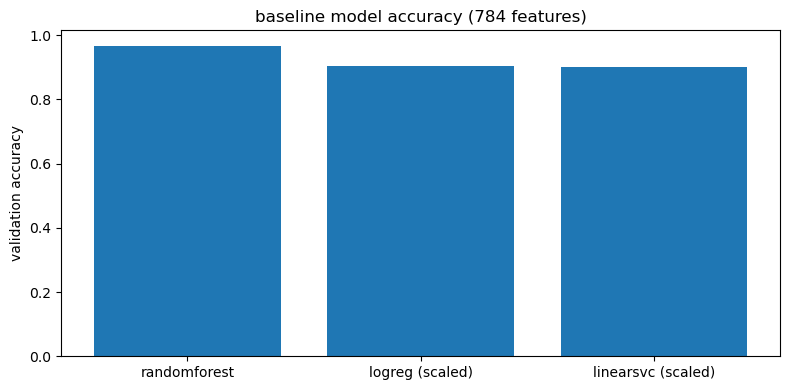

In [17]:
#accuracy comparison for baseline models
plt.figure(figsize=(8, 4))
plt.bar(baseline_df["model"], baseline_df["accuracy"])
plt.ylabel("validation accuracy")
plt.title("baseline model accuracy (784 features)")
plt.tight_layout()
plt.show()

Baseline Training time comparison

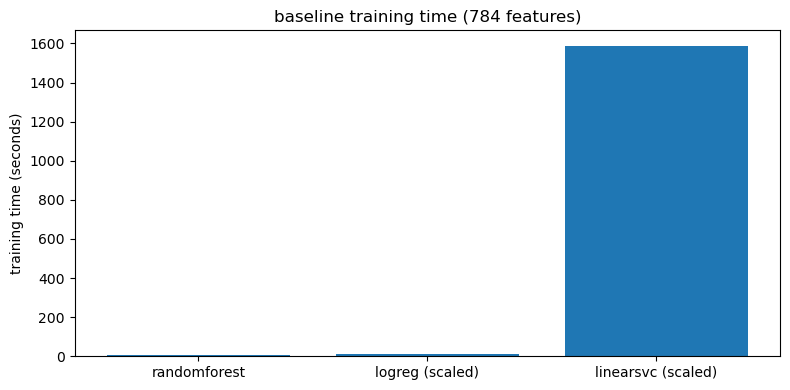

In [20]:
#training time comparison for baseline models
plt.figure(figsize=(8, 4))
plt.bar(baseline_df["model"], baseline_df["train_time_sec"])
plt.ylabel("training time (seconds)")
plt.title("baseline training time (784 features)")
plt.tight_layout()
plt.show()

PCA explained Variance (KEY for PRESENTATION AJ LOOOOOK AT THIS)

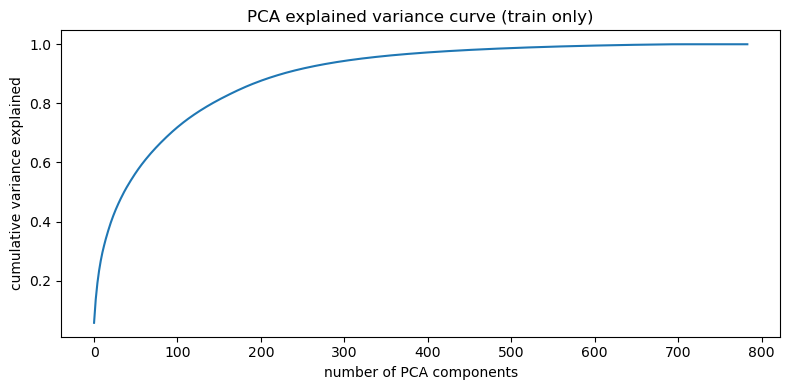

components: 25 variance explained: 0.4268
components: 50 variance explained: 0.561
components: 75 variance explained: 0.6497
components: 100 variance explained: 0.7172
components: 150 variance explained: 0.8114


In [40]:
#PCA based on variance so have to scale
#I ONLY fit PCA on the training data so there wasn't any leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca_full = PCA()
pca_full.fit(X_train_scaled)

#Cumulative explained variance helps me decide how many components might be enough
cum_var = np.cumsum(pca_full.explained_variance_ratio_)


plt.figure(figsize=(8, 4))
plt.plot(cum_var)
plt.xlabel("number of PCA components")
plt.ylabel("cumulative variance explained")
plt.title("PCA explained variance curve (train only)")
plt.tight_layout()
plt.show()

#printing a few specific points so I can reference exact numbers
for k in [25, 50, 75, 100, 150]:
    print("components:", k, "variance explained:", round(cum_var[k-1], 4))

PCA Experiments Accuracy and time vs components

In [23]:
#the main experiment
#Testing a few PCA sizes to see the tradeoff between accuracy and speed
pca_components = [25, 50, 75, 100, 150]
results_pca = []  # store results for each component count

for k in pca_components:

    #pipeline: scale,pca,logistic regression
    pca_model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=k)),
        ("clf", LogisticRegression(max_iter=2000))
    ])

    #time the training just to compare efficiency
    start = time.time()
    pca_model.fit(X_train, y_train)
    train_time = time.time() - start

    #evaluate on validation set
    preds = pca_model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average="macro")

    #saving results so I can plot them after
    results_pca.append({
        "components": k,
        "accuracy": acc,
        "macro_f1": f1,
        "train_time_sec": train_time
    })

pca_df = pd.DataFrame(results_pca)
print(pca_df)

   components  accuracy  macro_f1  train_time_sec
0          25  0.878214  0.876532        2.433489
1          50  0.902976  0.901518        5.070170
2          75  0.911429  0.910209        3.541397
3         100  0.917024  0.915781       10.384638
4         150  0.919405  0.918213        7.103840


Accuracy vs PCA components

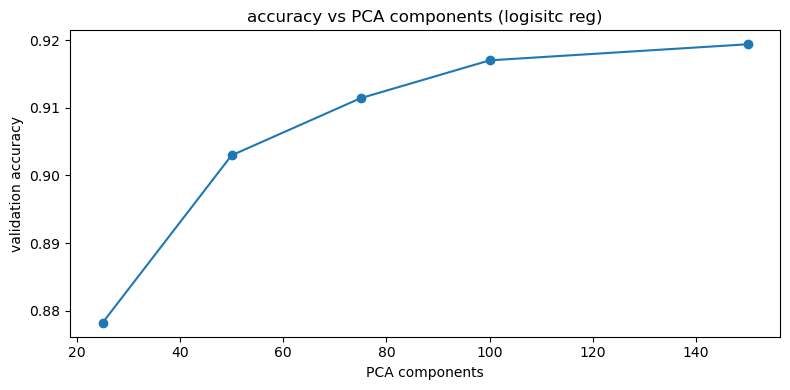

In [34]:
#this plot answers the big question: does reducing features hurt accuracy?
plt.figure(figsize=(8, 4))
plt.plot(pca_df["components"], pca_df["accuracy"], marker="o")
plt.xlabel("PCA components")
plt.ylabel("validation accuracy")
plt.title("accuracy vs PCA components (logisitc reg)")
plt.tight_layout()
plt.show()

Training time vs PcA components

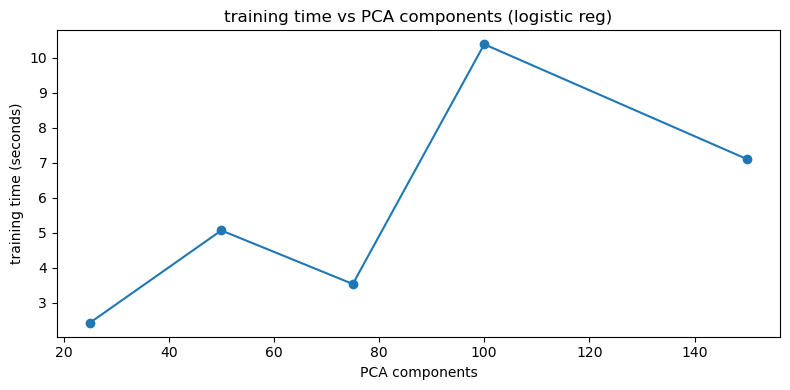

In [33]:
#this plot answers the efficiency part: do fewer components train faster?
plt.figure(figsize=(8, 4))
plt.plot(pca_df["components"], pca_df["train_time_sec"], marker="o")
plt.xlabel("PCA components")
plt.ylabel("training time (seconds)")
plt.title("training time vs PCA components (logistic reg)")
plt.tight_layout()
plt.show()

Confusion matrix and Error Analysis report

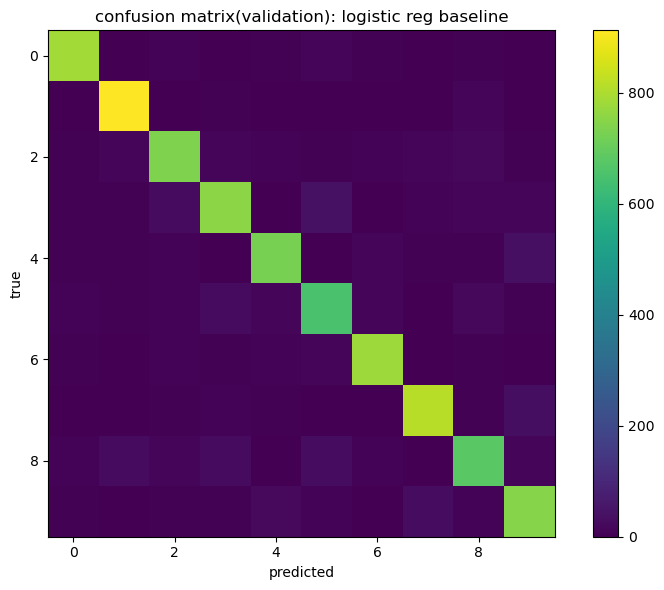

classification reportt (validation):
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       827
           1       0.93      0.97      0.95       937
           2       0.89      0.88      0.88       835
           3       0.89      0.87      0.88       870
           4       0.92      0.89      0.90       814
           5       0.84      0.86      0.85       759
           6       0.93      0.94      0.94       827
           7       0.93      0.93      0.93       880
           8       0.87      0.84      0.85       813
           9       0.87      0.89      0.88       838

    accuracy                           0.90      8400
   macro avg       0.90      0.90      0.90      8400
weighted avg       0.90      0.90      0.90      8400



In [41]:
#Error analysis: Im using baseline logistic regression here because it’s simple
#I could also swap this to the best model by accuracy if I want
best_model = log_model
best_model.fit(X_train, y_train)
best_preds = best_model.predict(X_val)

#confusion matrix shows which digits get mixed up
cm = confusion_matrix(y_val, best_preds)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("confusion matrix(validation): logistic reg baseline")
plt.xlabel("predicted")
plt.ylabel("true")
plt.colorbar()
plt.tight_layout()
plt.show()

#helpful for the weak spots
print("classification reportt (validation):")
print(classification_report(y_val, best_preds))

In [35]:
#finally I compared the best baseiline accuracy
#with the best PCA accuracy directly

best_baseline_acc = baseline_df["accuracy"].max()
best_pca_acc = pca_df["accuracy"].max()

print("Best baseline accuracy:", round(best_baseline_acc, 4))
print("Best PCA accuracy:", round(best_pca_acc, 4))

Best baseline accuracy: 0.9667
Best PCA accuracy: 0.9194


The random forest model with all 784 pixel features perfroimed the best at about 96.7% accuracy. After applying PCA, the accuracy dropped to around 91.9% which shows that reducing dimensions comes with some loss in performance. In this case, keeping the full feature set worked better.